In [1]:
import tensorflow as tf
import pandas as pd
import seaborn as sns

In [2]:
filepath = "../../Resources/Computer Vision in TensorFlow[2025]/train.csv"

In [3]:
data = pd.read_csv(filepath)
data.head()

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
0,1,535651,798186,3,78945,1,2,14,177,73,123,351318.0
1,2,591911,861056,6,117220,5,9,9,148,74,95,285001.5
2,3,686990,770762,2,132538,2,8,15,181,53,97,215386.0
3,4,573999,722381,4,101065,4,3,11,197,54,116,244295.5
4,5,691388,811335,6,61559,3,9,12,160,53,105,531114.5


In [4]:
data.describe()

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.00000
mean,500.500000,601648.286000,799131.3970,4.561000,100274.430000,2.988000,5.592000,11.625000,166.89300,84.54600,103.423000,308520.24250
std,288.819436,58407.246204,57028.9502,1.719079,29150.463233,1.402791,2.824449,2.230549,19.28838,20.51694,21.058716,126073.25915
min,1.000000,500265.000000,700018.0000,2.000000,50324.000000,1.000000,1.000000,8.000000,135.00000,50.00000,68.000000,28226.50000
25%,250.750000,548860.500000,750997.7500,3.000000,74367.500000,2.000000,3.000000,10.000000,150.00000,67.00000,85.000000,206871.75000
50%,500.500000,601568.000000,798168.0000,5.000000,100139.500000,3.000000,6.000000,12.000000,166.00000,84.00000,104.000000,306717.75000
75%,750.250000,652267.250000,847563.2500,6.000000,125048.000000,4.000000,8.000000,13.000000,184.00000,102.00000,121.000000,414260.87500
max,1000.000000,699859.000000,899797.0000,7.000000,149902.000000,5.000000,10.000000,15.000000,200.00000,120.00000,140.000000,584267.50000


In [5]:
data.shape

(1000, 12)

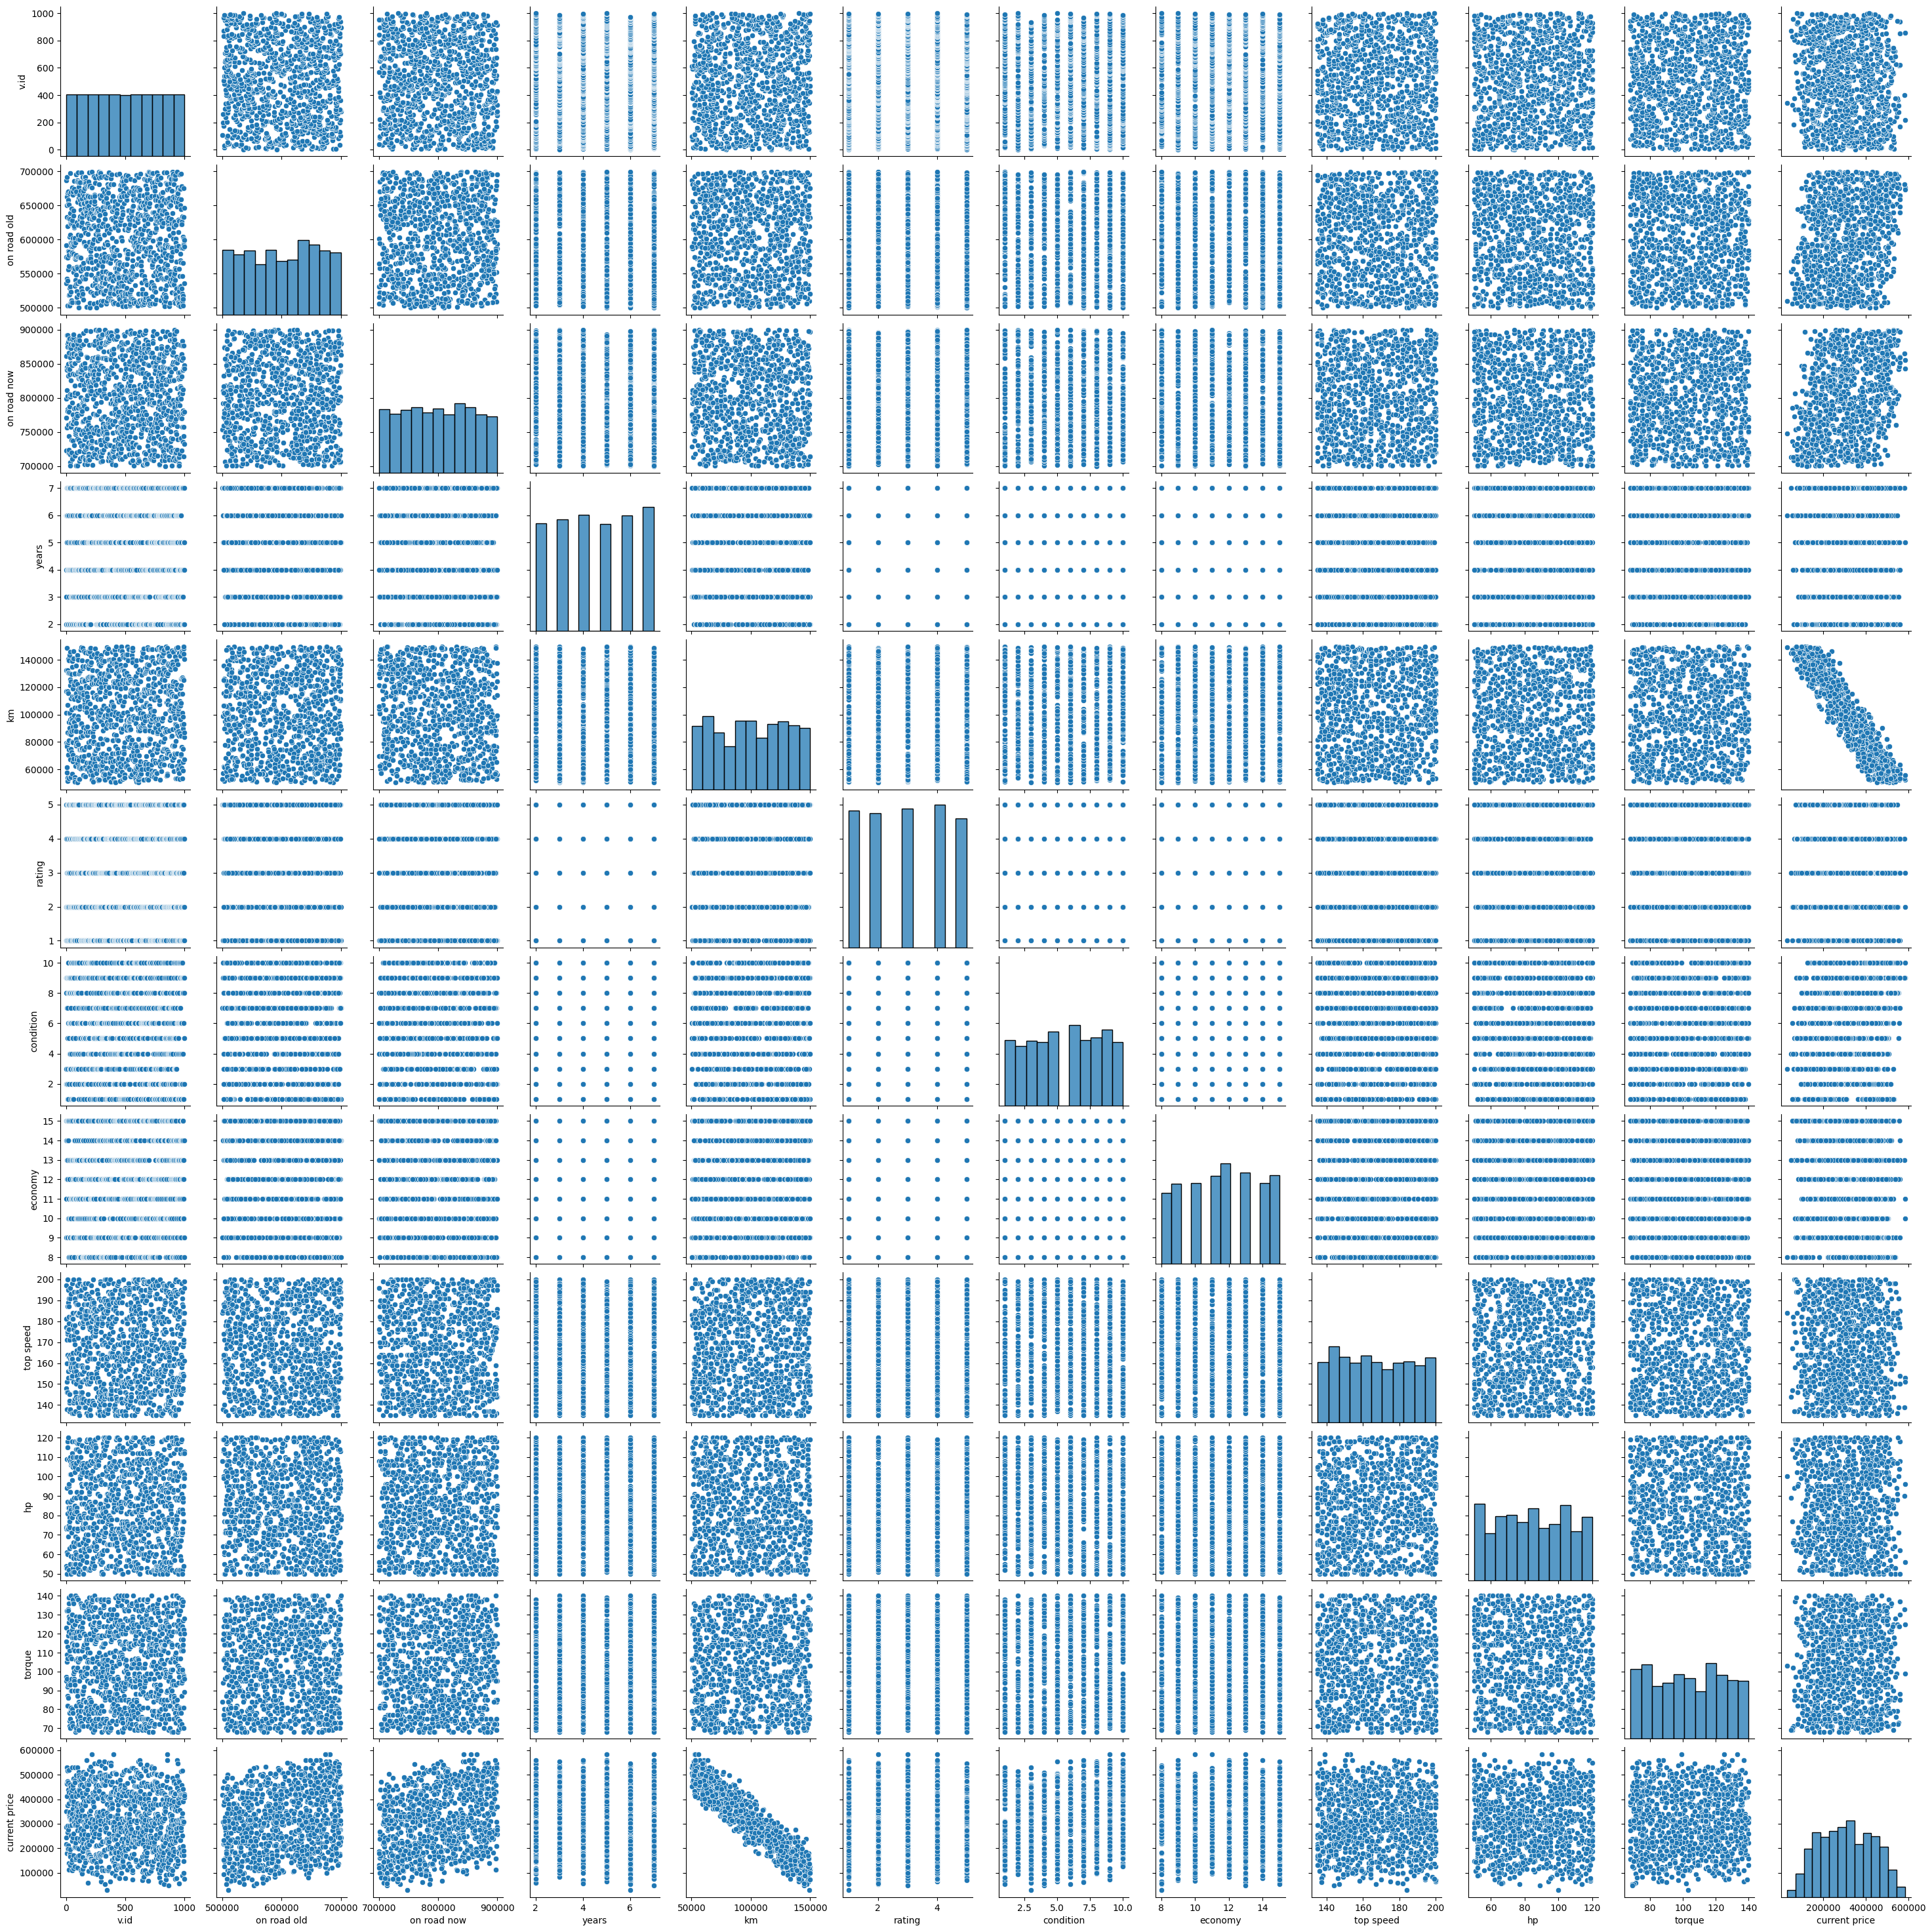

In [6]:
sns.pairplot(data)

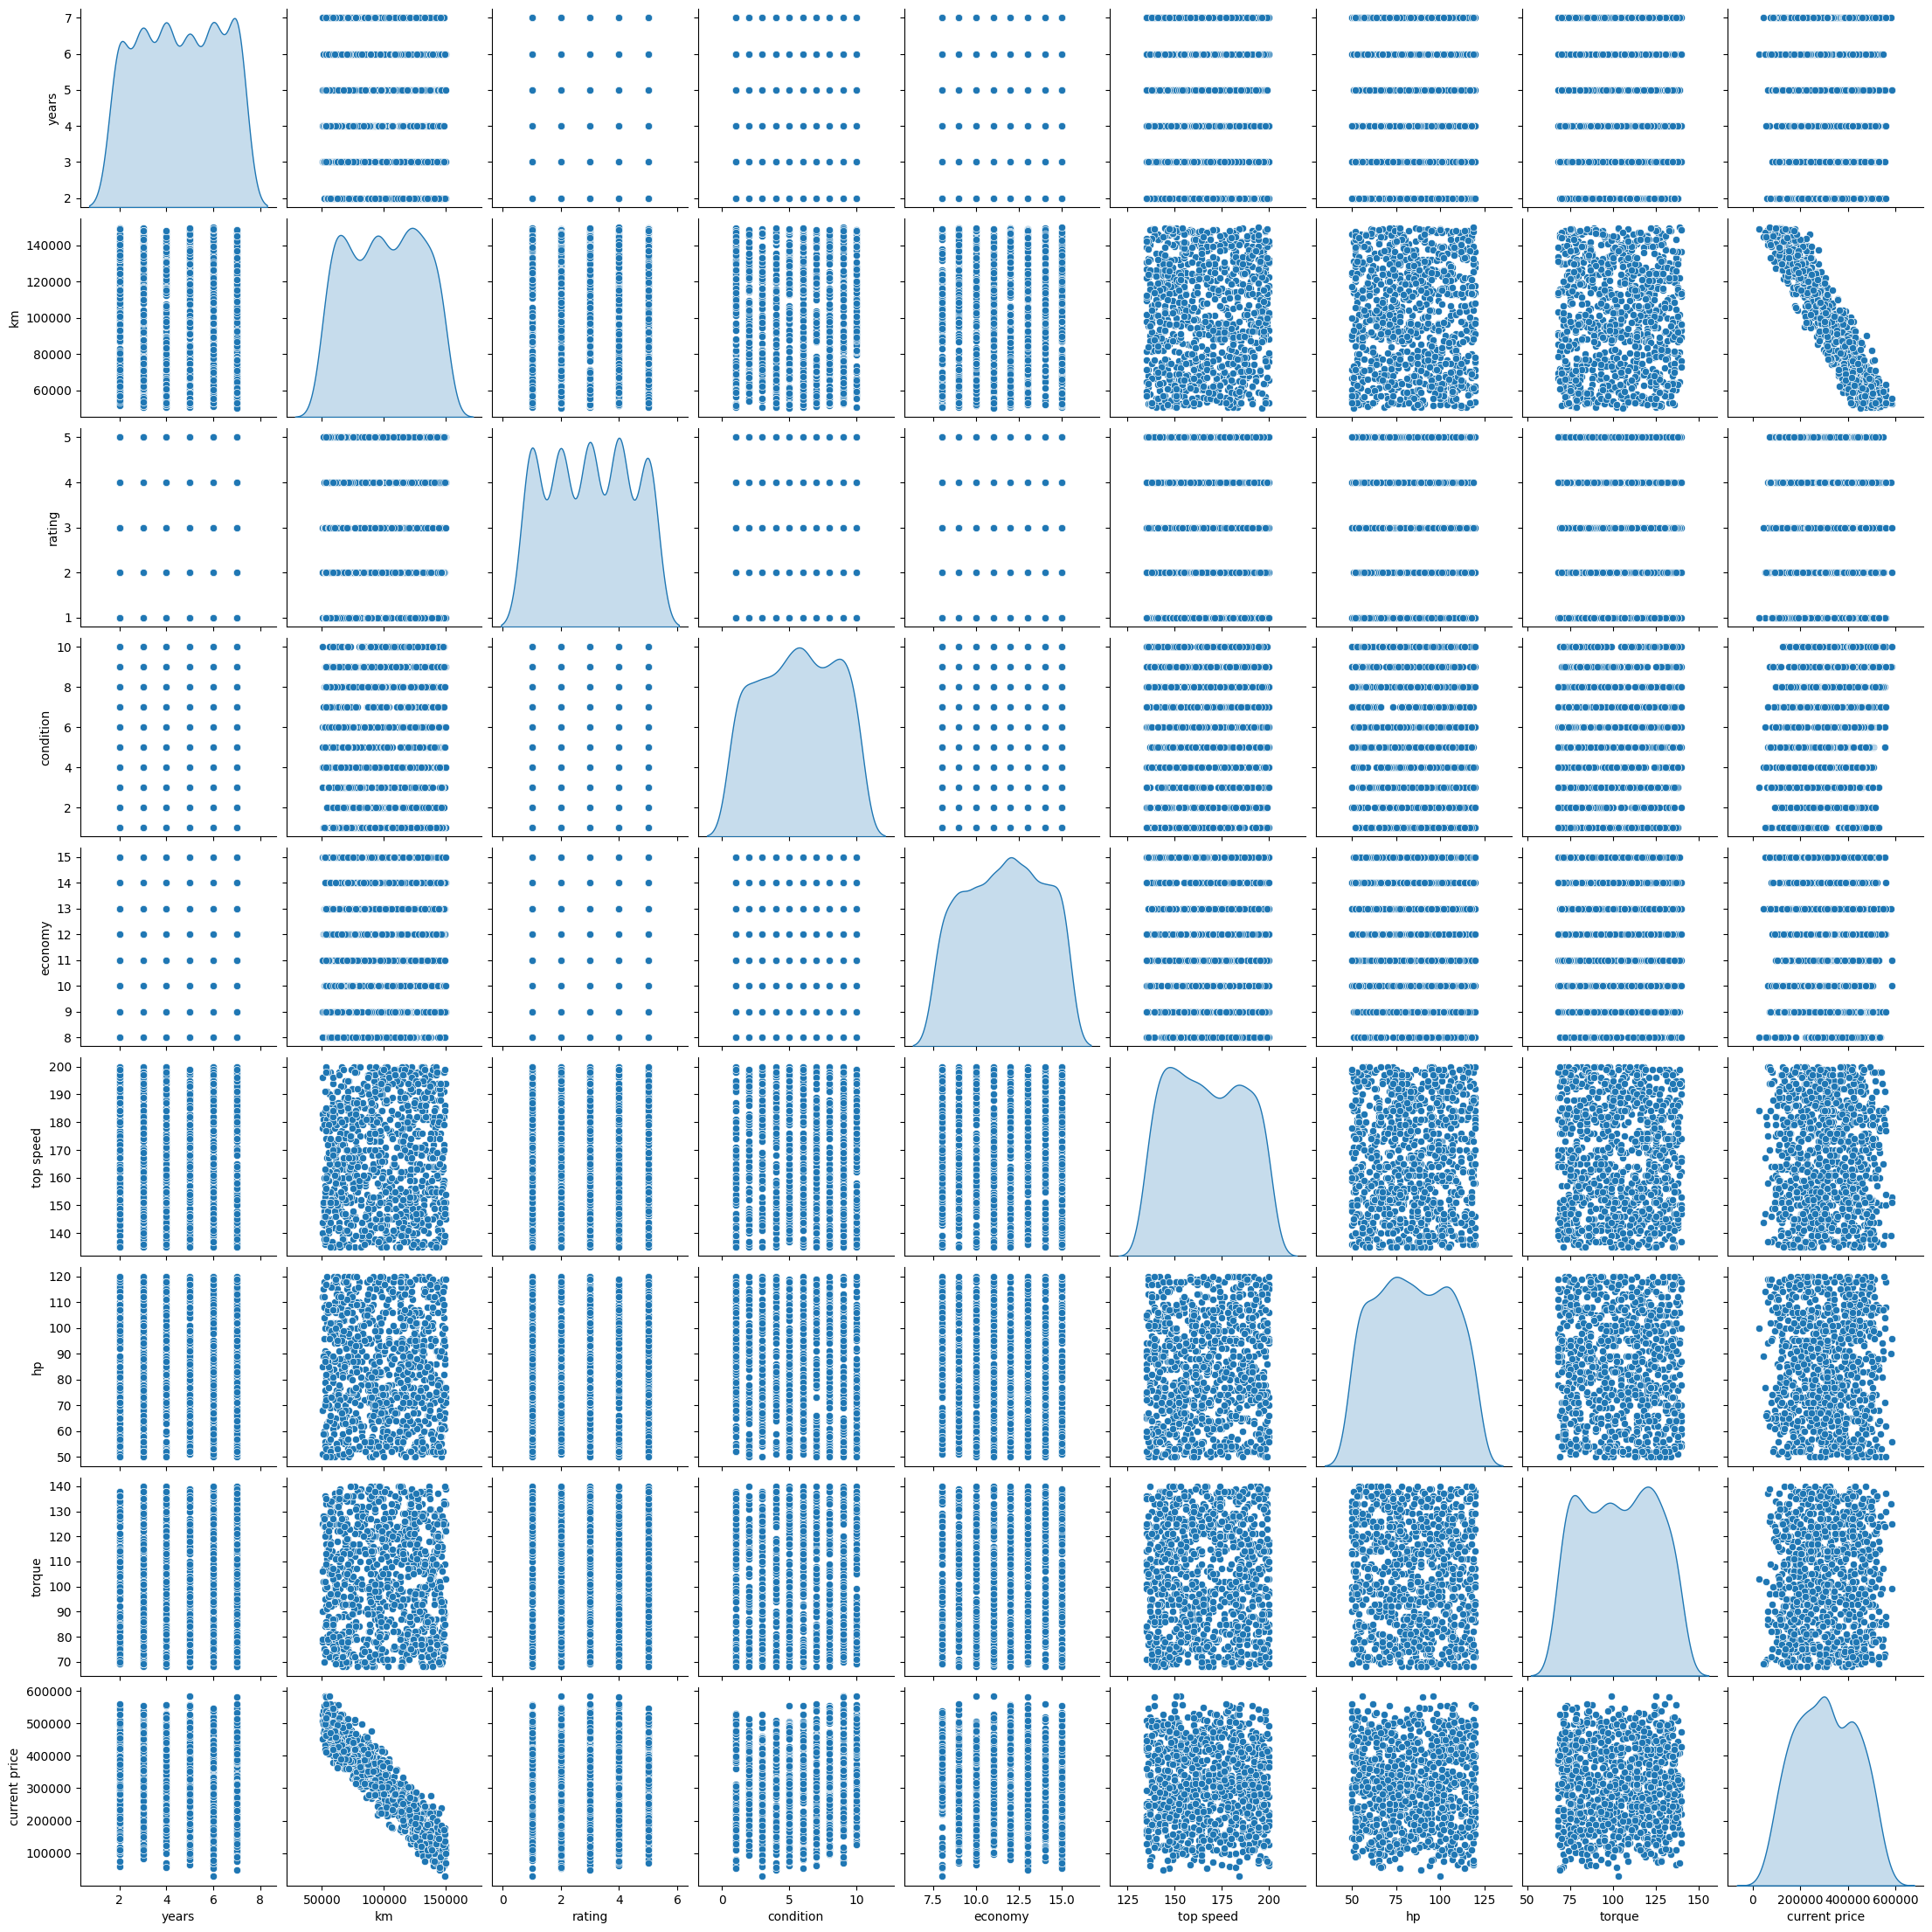

In [7]:
sns.pairplot(data[['years', 'km', 'rating', 'condition', 'economy', 'top speed', 'hp', 'torque', 'current price']], diag_kind='kde')

### Data Preparation


In [8]:
data.isnull().sum()

v.id             0
on road old      0
on road now      0
years            0
km               0
rating           0
condition        0
economy          0
top speed        0
hp               0
torque           0
current price    0
dtype: int64

In [9]:
tensor_data = tf.constant(data)
tensor_data = tf.cast(tensor_data, tf.float32)
tensor_data

<tf.Tensor: shape=(1000, 12), dtype=float32, numpy=
array([[1.000000e+00, 5.356510e+05, 7.981860e+05, ..., 7.300000e+01,
        1.230000e+02, 3.513180e+05],
       [2.000000e+00, 5.919110e+05, 8.610560e+05, ..., 7.400000e+01,
        9.500000e+01, 2.850015e+05],
       [3.000000e+00, 6.869900e+05, 7.707620e+05, ..., 5.300000e+01,
        9.700000e+01, 2.153860e+05],
       ...,
       [9.980000e+02, 6.463440e+05, 8.427330e+05, ..., 1.130000e+02,
        8.900000e+01, 4.058710e+05],
       [9.990000e+02, 5.355590e+05, 7.324390e+05, ..., 1.120000e+02,
        1.280000e+02, 7.439800e+04],
       [1.000000e+03, 5.901050e+05, 7.797430e+05, ..., 9.900000e+01,
        9.600000e+01, 4.149385e+05]], shape=(1000, 12), dtype=float32)>

In [10]:
shuffled_data = tf.random.shuffle(tensor_data)
shuffled_data[:5]

<tf.Tensor: shape=(5, 12), dtype=float32, numpy=
array([[8.690000e+02, 5.531930e+05, 7.132450e+05, 7.000000e+00,
        1.446910e+05, 3.000000e+00, 4.000000e+00, 1.300000e+01,
        1.440000e+02, 8.900000e+01, 6.900000e+01, 4.692050e+04],
       [6.610000e+02, 5.079830e+05, 7.618110e+05, 3.000000e+00,
        1.165870e+05, 3.000000e+00, 2.000000e+00, 1.400000e+01,
        1.690000e+02, 9.000000e+01, 1.240000e+02, 1.688545e+05],
       [3.750000e+02, 5.498950e+05, 7.922330e+05, 5.000000e+00,
        9.573000e+04, 5.000000e+00, 8.000000e+00, 1.400000e+01,
        1.700000e+02, 9.100000e+01, 1.230000e+02, 3.048180e+05],
       [3.890000e+02, 6.569560e+05, 7.966380e+05, 6.000000e+00,
        6.276800e+04, 1.000000e+00, 1.000000e+00, 1.300000e+01,
        1.650000e+02, 7.300000e+01, 7.900000e+01, 4.720810e+05],
       [6.650000e+02, 6.209630e+05, 8.295110e+05, 3.000000e+00,
        9.551300e+04, 2.000000e+00, 3.000000e+00, 8.000000e+00,
        1.530000e+02, 1.180000e+02, 9.600000e+01, 3

In [11]:
data.head()

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
0,1,535651,798186,3,78945,1,2,14,177,73,123,351318.0
1,2,591911,861056,6,117220,5,9,9,148,74,95,285001.5
2,3,686990,770762,2,132538,2,8,15,181,53,97,215386.0
3,4,573999,722381,4,101065,4,3,11,197,54,116,244295.5
4,5,691388,811335,6,61559,3,9,12,160,53,105,531114.5


In [12]:
X = shuffled_data[:, 3:-1]
y = shuffled_data[:, -1]
X[:5], y[:5]

(<tf.Tensor: shape=(5, 8), dtype=float32, numpy=
 array([[7.00000e+00, 1.44691e+05, 3.00000e+00, 4.00000e+00, 1.30000e+01,
         1.44000e+02, 8.90000e+01, 6.90000e+01],
        [3.00000e+00, 1.16587e+05, 3.00000e+00, 2.00000e+00, 1.40000e+01,
         1.69000e+02, 9.00000e+01, 1.24000e+02],
        [5.00000e+00, 9.57300e+04, 5.00000e+00, 8.00000e+00, 1.40000e+01,
         1.70000e+02, 9.10000e+01, 1.23000e+02],
        [6.00000e+00, 6.27680e+04, 1.00000e+00, 1.00000e+00, 1.30000e+01,
         1.65000e+02, 7.30000e+01, 7.90000e+01],
        [3.00000e+00, 9.55130e+04, 2.00000e+00, 3.00000e+00, 8.00000e+00,
         1.53000e+02, 1.18000e+02, 9.60000e+01]], dtype=float32)>,
 <tf.Tensor: shape=(5,), dtype=float32, numpy=array([ 46920.5, 168854.5, 304818. , 472081. , 343416.5], dtype=float32)>)

In [13]:
X.shape, y.shape

(TensorShape([1000, 8]), TensorShape([1000]))

In [14]:
# need to make y as 2d array for tensorflow
y = tf.expand_dims(shuffled_data[:, -1], axis=1)
y.shape

TensorShape([1000, 1])

In [15]:
X.shape, y.shape

(TensorShape([1000, 8]), TensorShape([1000, 1]))

#### Normalization


In [ ]:
from tensorflow.keras.layers import Normalization, Dense, InputLayer

In [ ]:
### Random example of normalization layer
a = tf.constant([2,3,4,5,6,7])
normalizer = Normalization()
normalizer(a)

In [ ]:
normalizer = Normalization(mean=5, variance=3)
normalizer(a)

In [ ]:
a = tf.constant([[2,3,4,5,6,7],[4,5,6,7,8,9]])
normalizer = Normalization(mean=5, variance=3)
normalizer(a)

In [ ]:
a = tf.constant([[2,3,4,5,6,7],
                 [4,5,6,7,8,9],
                 [9,6,4,5,2,1]])
normalizer = Normalization(axis=-1)
normalizer.adapt(a)
normalizer(a)

In [ ]:
### Normalization layer for our data

normalizer = Normalization(axis=-1)
normalizer.adapt(X) 
X_normalized = normalizer(X)
X_normalized

In [ ]:
model = tf.keras.Sequential([
    InputLayer(input_shape=(8, )),
    normalizer,
    Dense(1)
], name="sequencial-model-api-01")
model.summary()

In [ ]:
model.build()

In [ ]:
tf.keras.utils.plot_model(
    model,
    to_file="model_plot.png",
    show_shapes=True,
)

### Training


In [ ]:
print(X.shape, y.shape)

In [ ]:
model.compile(optimizer='sgd', loss=tf.keras.losses.Huber())

In [ ]:
model.fit(X, y, epochs=100, verbose=1)

In [ ]:
from tensorflow.keras.optimizers import Adam, AdamW

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-3), loss=tf.keras.losses.Huber())

In [ ]:
history = model.fit(X, y, epochs=100, verbose=1)

In [ ]:
history.history

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'])
plt.show()

In [ ]:
from tensorflow.keras.metrics import RootMeanSquaredError

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-3), 
              loss=tf.keras.losses.MeanAbsoluteError(),
              metrics=[RootMeanSquaredError()]
              )

In [ ]:
history = model.fit(X, y, epochs=100, verbose=1)

In [ ]:
plt.plot(history.history['root_mean_squared_error'])
plt.title('model performance')
plt.ylabel('rmse')
plt.xlabel('epoch')
plt.legend(['train'])
plt.show()

In [ ]:
model.evaluate(X, y)

## Normalizing


In [16]:
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
DATASET_SIZE = len(X)
DATASET_SIZE

1000

In [17]:
X_train = X[:int(DATASET_SIZE * TRAIN_RATIO)]
y_train = y[:int(DATASET_SIZE * TRAIN_RATIO)]
X_train.shape, y_train.shape

(TensorShape([800, 8]), TensorShape([800, 1]))

In [18]:
X_val = X[int(DATASET_SIZE * TRAIN_RATIO):int(DATASET_SIZE * (TRAIN_RATIO + VAL_RATIO))]
y_val = y[int(DATASET_SIZE * TRAIN_RATIO):int(DATASET_SIZE * (TRAIN_RATIO + VAL_RATIO))]
X_val.shape, y_val.shape

(TensorShape([100, 8]), TensorShape([100, 1]))

In [19]:
X_test = X[int(DATASET_SIZE * (TRAIN_RATIO + VAL_RATIO)):]
y_test = y[int(DATASET_SIZE * (TRAIN_RATIO + VAL_RATIO)):]
X_test.shape, y_test.shape

(TensorShape([100, 8]), TensorShape([100, 1]))

In [42]:
from tensorflow.keras.layers import Normalization, Dense, InputLayer
normalizer = Normalization()
normalizer.adapt(X_train)
normalizer(X_train)[:5]

<tf.Tensor: shape=(5, 8), dtype=float32, numpy=
array([[ 1.398589  ,  1.5302489 ,  0.00528683, -0.5612961 ,  0.6403686 ,
        -1.1922985 ,  0.22702108, -1.6452323 ],
       [-0.9143233 ,  0.5600368 ,  0.00528683, -1.2607305 ,  1.0897499 ,
         0.08637442,  0.27618647,  0.95648646],
       [ 0.2421329 , -0.1599929 ,  1.4151212 ,  0.83757263,  1.0897499 ,
         0.13752134,  0.32535183,  0.9091825 ],
       [ 0.82036096, -1.2979139 , -1.4045475 , -1.6104476 ,  0.6403686 ,
        -0.11821326, -0.55962473, -1.1721925 ],
       [-0.9143233 , -0.16748422, -0.6996303 , -0.91101325, -1.6065384 ,
        -0.7319763 ,  1.6528167 , -0.3680249 ]], dtype=float32)>

In [24]:
model = tf.keras.Sequential([
    normalizer,
    Dense(1)
], 
name = "first-model-001"
)
model.summary()

Model: "first-model-001"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (800, 8)               │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (72.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17 (72.00 B)

In [26]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.1),
              loss = tf.keras.losses.MeanAbsoluteError(),
              metrics = [tf.keras.metrics.RootMeanSquaredError()],
              )

#### Training approach 1


In [27]:
history = model.fit(X_train, y_train, 
                    epochs=100, 
                    verbose=1,
                    validation_data=(X_val, y_val)
                    )

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 308732.0938 - root_mean_squared_error: 333692.5938 - val_loss: 323244.6875 - val_root_mean_squared_error: 346030.3125
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 308729.5312 - root_mean_squared_error: 333690.2500 - val_loss: 323242.2500 - val_root_mean_squared_error: 346028.0938
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 308727.0312 - root_mean_squared_error: 333687.9062 - val_loss: 323239.7188 - val_root_mean_squared_error: 346025.6250
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 308724.5312 - root_mean_squared_error: 333685.6250 - val_loss: 323237.2500 - val_root_mean_squared_error: 346023.4062
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 308722.0312 - root_mean_squared_error: 333683.2812 - val_loss: 323234.7188 - val_root_mean_squared_error: 346021.0312
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 308719.5312 - root_mean_squared_error: 333680.9375 - val

In [28]:
model.summary()

Model: "first-model-001"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (32, 8)                │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 1)                │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46 (192.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 17 (72.00 B)

 Optimizer params: 20 (84.00 B)

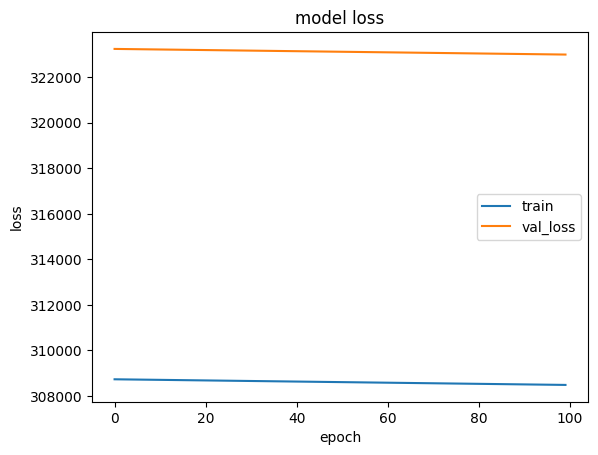

In [30]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val_loss'])
plt.show()

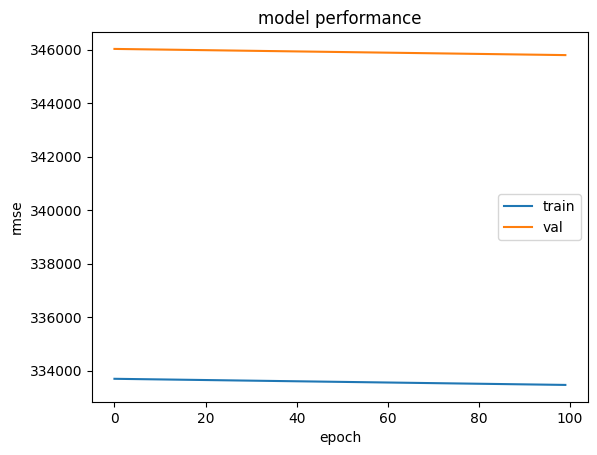

In [31]:
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('model performance')
plt.ylabel('rmse')
plt.xlabel('epoch')
plt.legend(['train', 'val'])
plt.show()

In [32]:
model.evaluate(X_val, y_val)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 322997.1875 - root_mean_squared_error: 345799.1875 


[322997.1875, 345799.1875]

In [33]:
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 291839.5312 - root_mean_squared_error: 316125.5625 


[291839.53125, 316125.5625]

In [34]:
X_test.shape, y_test.shape

(TensorShape([100, 8]), TensorShape([100, 1]))

In [35]:
model.predict(tf.expand_dims(X_test[0], axis = 0 ))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([[249.50099]], dtype=float32)

In [36]:
y_test[0]

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([253387.], dtype=float32)>

In [38]:
y_true = list(y_test[:,0].numpy())
y_true

[np.float32(253387.0),
 np.float32(272075.0),
 np.float32(133006.5),
 np.float32(174352.5),
 np.float32(318858.0),
 np.float32(177509.5),
 np.float32(317681.5),
 np.float32(294502.5),
 np.float32(304923.5),
 np.float32(195854.0),
 np.float32(171620.0),
 np.float32(459833.5),
 np.float32(289570.5),
 np.float32(295021.0),
 np.float32(553901.0),
 np.float32(196639.5),
 np.float32(417940.0),
 np.float32(235843.0),
 np.float32(262126.5),
 np.float32(223594.5),
 np.float32(253853.5),
 np.float32(373529.0),
 np.float32(273761.0),
 np.float32(528794.0),
 np.float32(93190.5),
 np.float32(313879.0),
 np.float32(107500.5),
 np.float32(422774.5),
 np.float32(251317.5),
 np.float32(201188.5),
 np.float32(77167.0),
 np.float32(355175.0),
 np.float32(265194.0),
 np.float32(179077.0),
 np.float32(413288.0),
 np.float32(330887.0),
 np.float32(278759.5),
 np.float32(206296.5),
 np.float32(344495.0),
 np.float32(351704.5),
 np.float32(438223.0),
 np.float32(120869.5),
 np.float32(283435.5),
 np.float32(1

In [39]:
y_pred = list(model.predict(X_test)[:,0])
print(y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[np.float32(249.50099), np.float32(246.39392), np.float32(246.7806), np.float32(249.38347), np.float32(250.69748), np.float32(248.90501), np.float32(253.53387), np.float32(246.48149), np.float32(250.75511), np.float32(247.47083), np.float32(245.15944), np.float32(247.48798), np.float32(246.5639), np.float32(246.3737), np.float32(252.08823), np.float32(250.70593), np.float32(251.2069), np.float32(250.623), np.float32(250.18239), np.float32(250.45726), np.float32(247.70856), np.float32(248.12311), np.float32(248.22119), np.float32(252.92006), np.float32(250.34868), np.float32(251.2664), np.float32(249.88536), np.float32(248.48042), np.float32(254.11882), np.float32(250.0907), np.float32(246.10464), np.float32(252.71077), np.float32(251.17348), np.float32(247.22453), np.float32(251.77032), np.float32(248.83649), np.float32(253.50565), np.float32(248.71703), np.float32(252.03589), np.float32(246.59897), np.float32(248.44307), np.float32(245.39021), np.

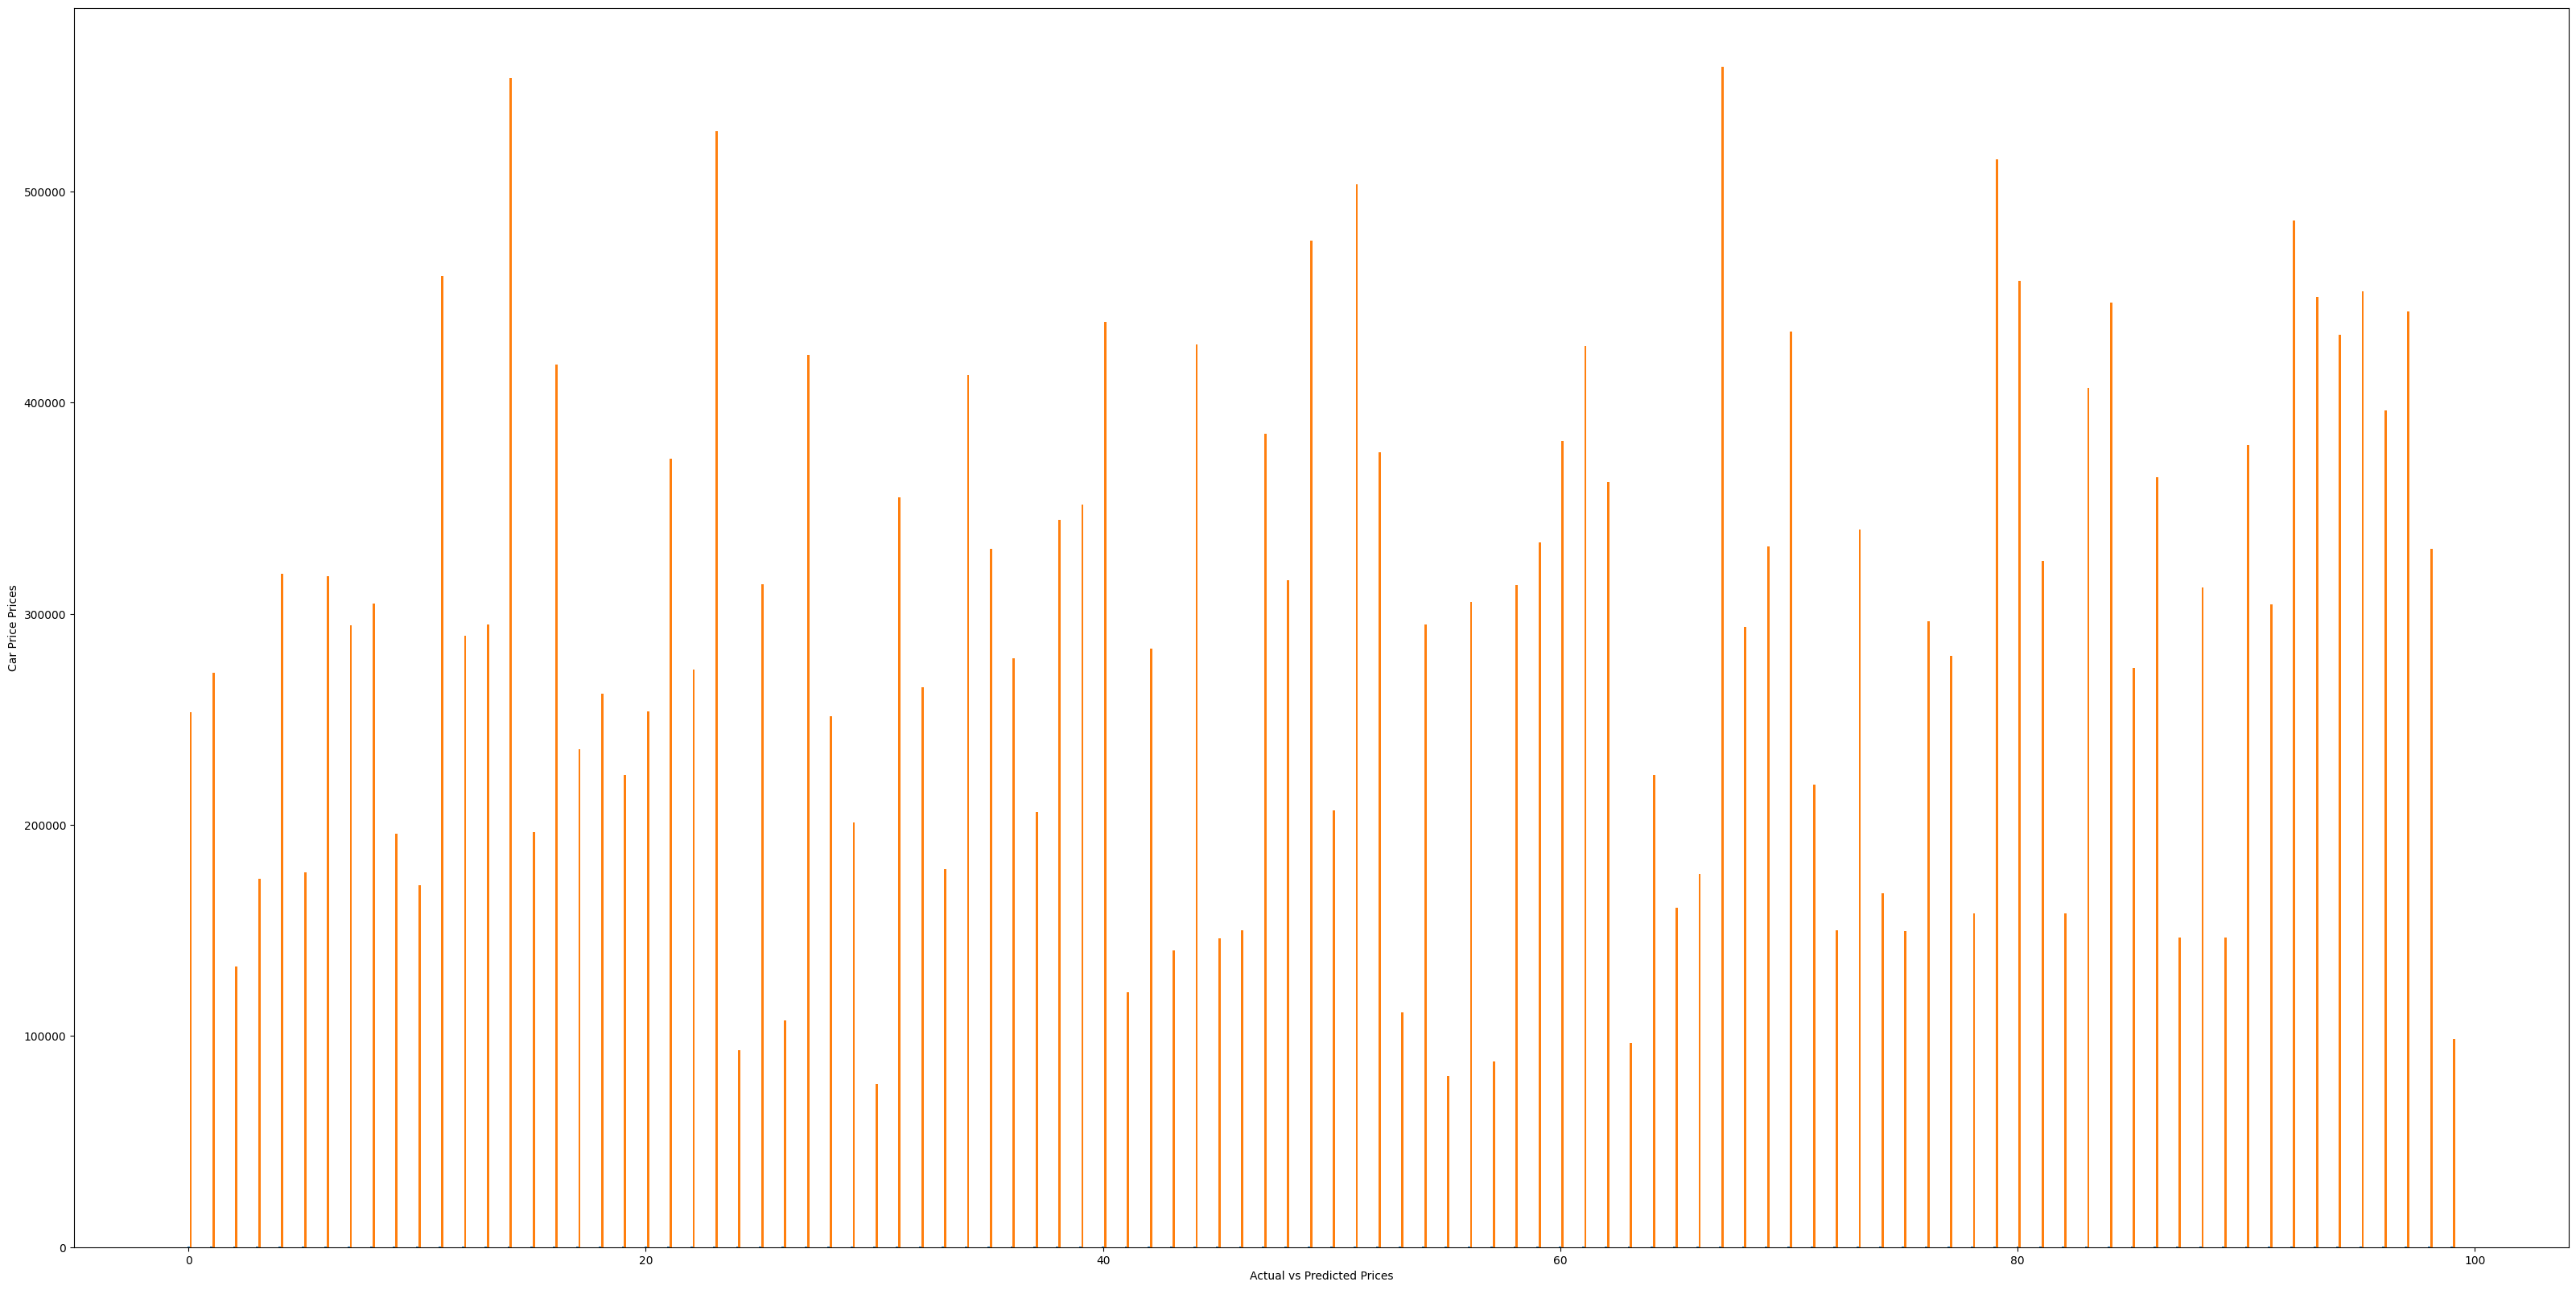

In [40]:
import numpy as np
ind = np.arange(100)
plt.figure(figsize=(40,20))

width = 0.1

plt.bar(ind, y_pred, width, label='Predicted Car Price')
plt.bar(ind + width, y_true, width, label='Actual Car Price')

plt.xlabel('Actual vs Predicted Prices')
plt.ylabel('Car Price Prices')

plt.show()

#### New model


In [43]:
model = tf.keras.Sequential([
    InputLayer((8,)),
    normalizer,
    Dense(128),
    Dense(128),
    Dense(128),
    Dense(1)
], 
name = "first-model-003"
)
model.summary()

Model: "first-model-003"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,322 (134.07 KB)

 Trainable params: 34,305 (134.00 KB)

 Non-trainable params: 17 (72.00 B)

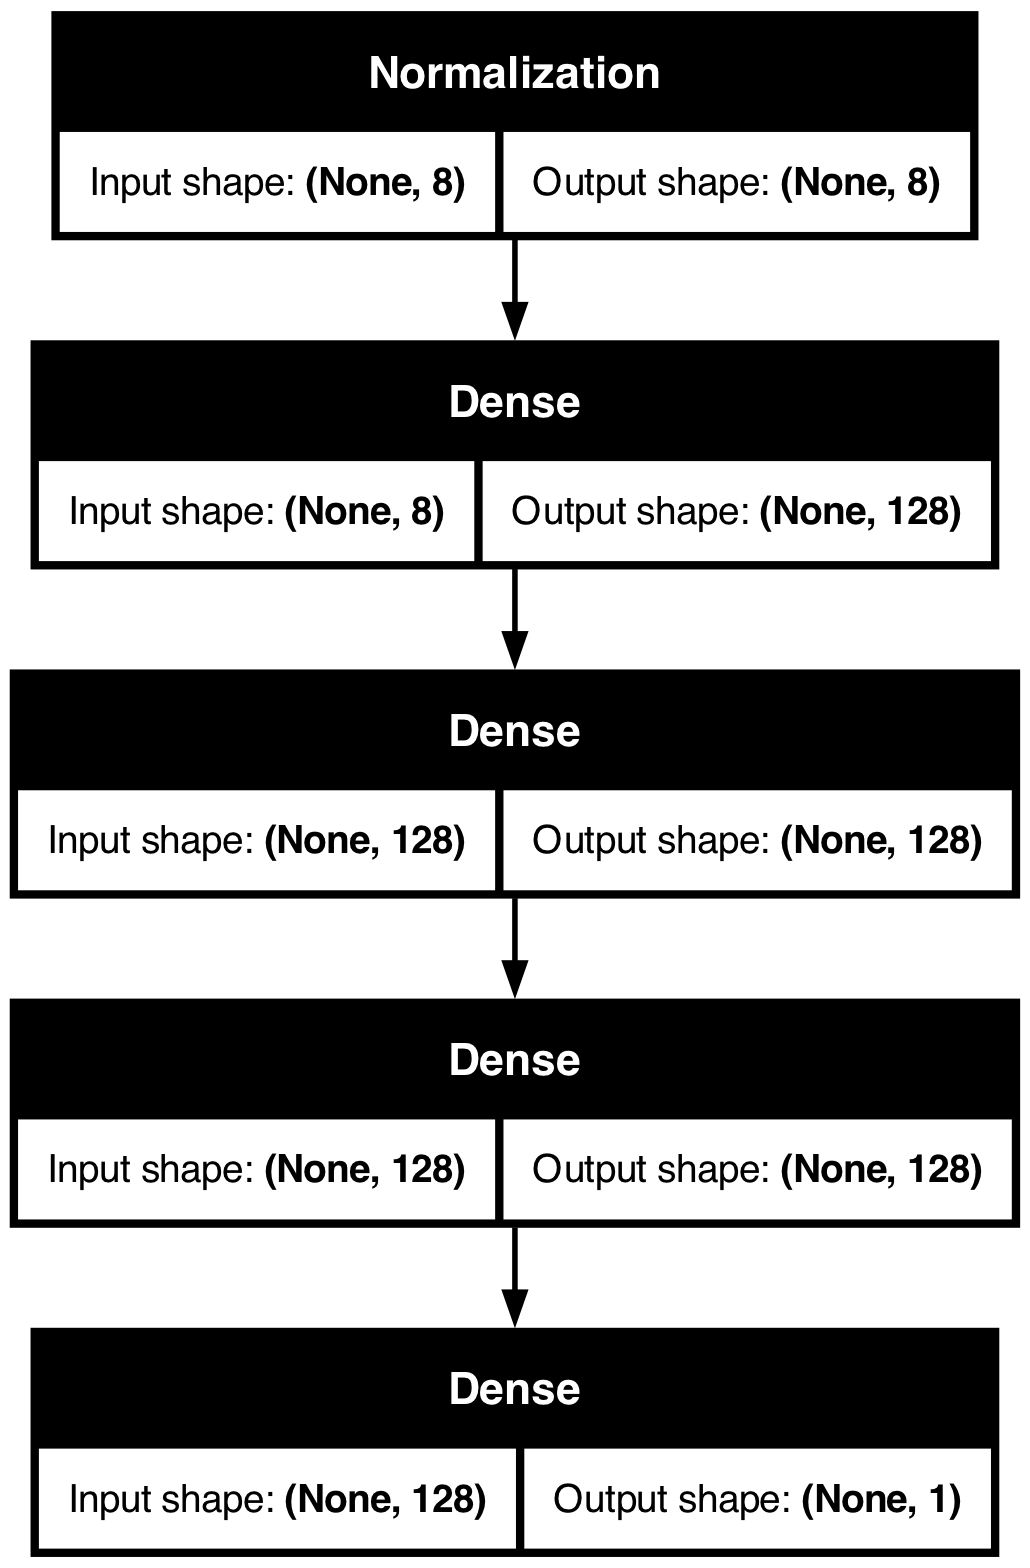

In [44]:
tf.keras.utils.plot_model(
    model,
    to_file = "model_plot_003.png",
    show_shapes = True
)

In [45]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.1),
              loss = tf.keras.losses.MeanAbsoluteError(),
              metrics = [tf.keras.metrics.RootMeanSquaredError()],
              )

In [46]:
history = model.fit(X_train, y_train, 
                    epochs=200, 
                    verbose=1,
                    validation_data=(X_val, y_val)
                    )

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 166617.1875 - root_mean_squared_error: 223187.3281 - val_loss: 39711.5664 - val_root_mean_squared_error: 50321.4922
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 49702.6992 - root_mean_squared_error: 62067.1836 - val_loss: 41619.9492 - val_root_mean_squared_error: 51650.1445
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 42894.0352 - root_mean_squared_error: 53193.9102 - val_loss: 48020.5352 - val_root_mean_squared_error: 57890.0820
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 47058.2031 - root_mean_squared_error: 59259.8750 - val_loss: 31801.5000 - val_root_mean_squared_error: 39164.7227
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 44277.0742 - root_mean_squared_error: 54627.1133 - val_loss: 32868.3828 - val_root_mean_squared_error: 41851.6875
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48857.8750 - root_mean_squared_error: 61676.9844 - val_loss: 36944.6406 - 

In [47]:
model.summary()

Model: "first-model-003"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,934 (402.09 KB)

 Trainable params: 34,305 (134.00 KB)

 Non-trainable params: 17 (72.00 B)

 Optimizer params: 68,612 (268.02 KB)

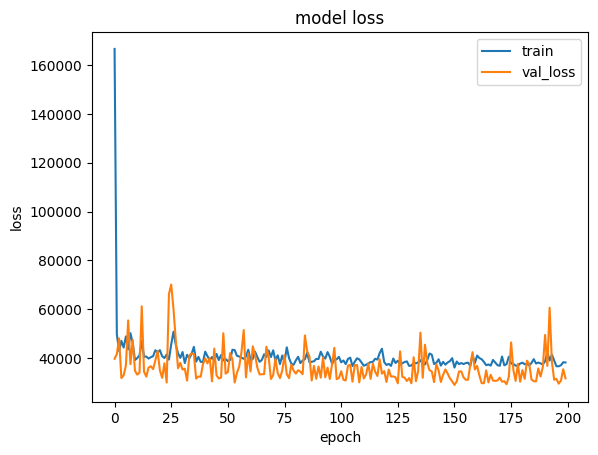

In [48]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val_loss'])
plt.show()

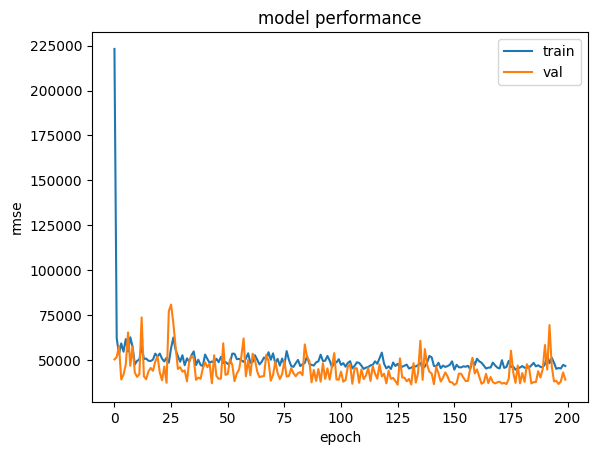

In [49]:
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('model performance')
plt.ylabel('rmse')
plt.xlabel('epoch')
plt.legend(['train', 'val'])
plt.show()

In [50]:
model.evaluate(X_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 43488.0391 - root_mean_squared_error: 51435.7852  


[43488.0390625, 51435.78515625]

In [51]:
X_test.shape, y_test.shape

(TensorShape([100, 8]), TensorShape([100, 1]))

In [52]:
y_true = list(y_test[:,0].numpy())

In [53]:
y_pred = list(model.predict(X_test)[:,0])
print(y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[np.float32(238101.53), np.float32(207890.69), np.float32(102438.71), np.float32(112553.414), np.float32(377703.7), np.float32(200772.47), np.float32(340292.56), np.float32(284309.38), np.float32(244001.16), np.float32(180590.16), np.float32(101114.34), np.float32(363946.2), np.float32(212014.52), np.float32(221207.61), np.float32(484787.75), np.float32(118597.36), np.float32(374576.22), np.float32(203712.4), np.float32(226428.78), np.float32(295547.3), np.float32(296040.3), np.float32(357797.2), np.float32(278378.03), np.float32(490159.88), np.float32(137691.83), np.float32(274219.34), np.float32(104249.555), np.float32(314468.88), np.float32(276193.97), np.float32(159153.44), np.float32(130966.836), np.float32(406827.06), np.float32(209177.53), np.float32(118102.13), np.float32(405268.2), np.float32(287584.56), np.float32(338487.44), np.float32(198412.52), np.float32(275476.97), np.float32(299087.34), np.float32(432527.56), np.float32(169204.95),

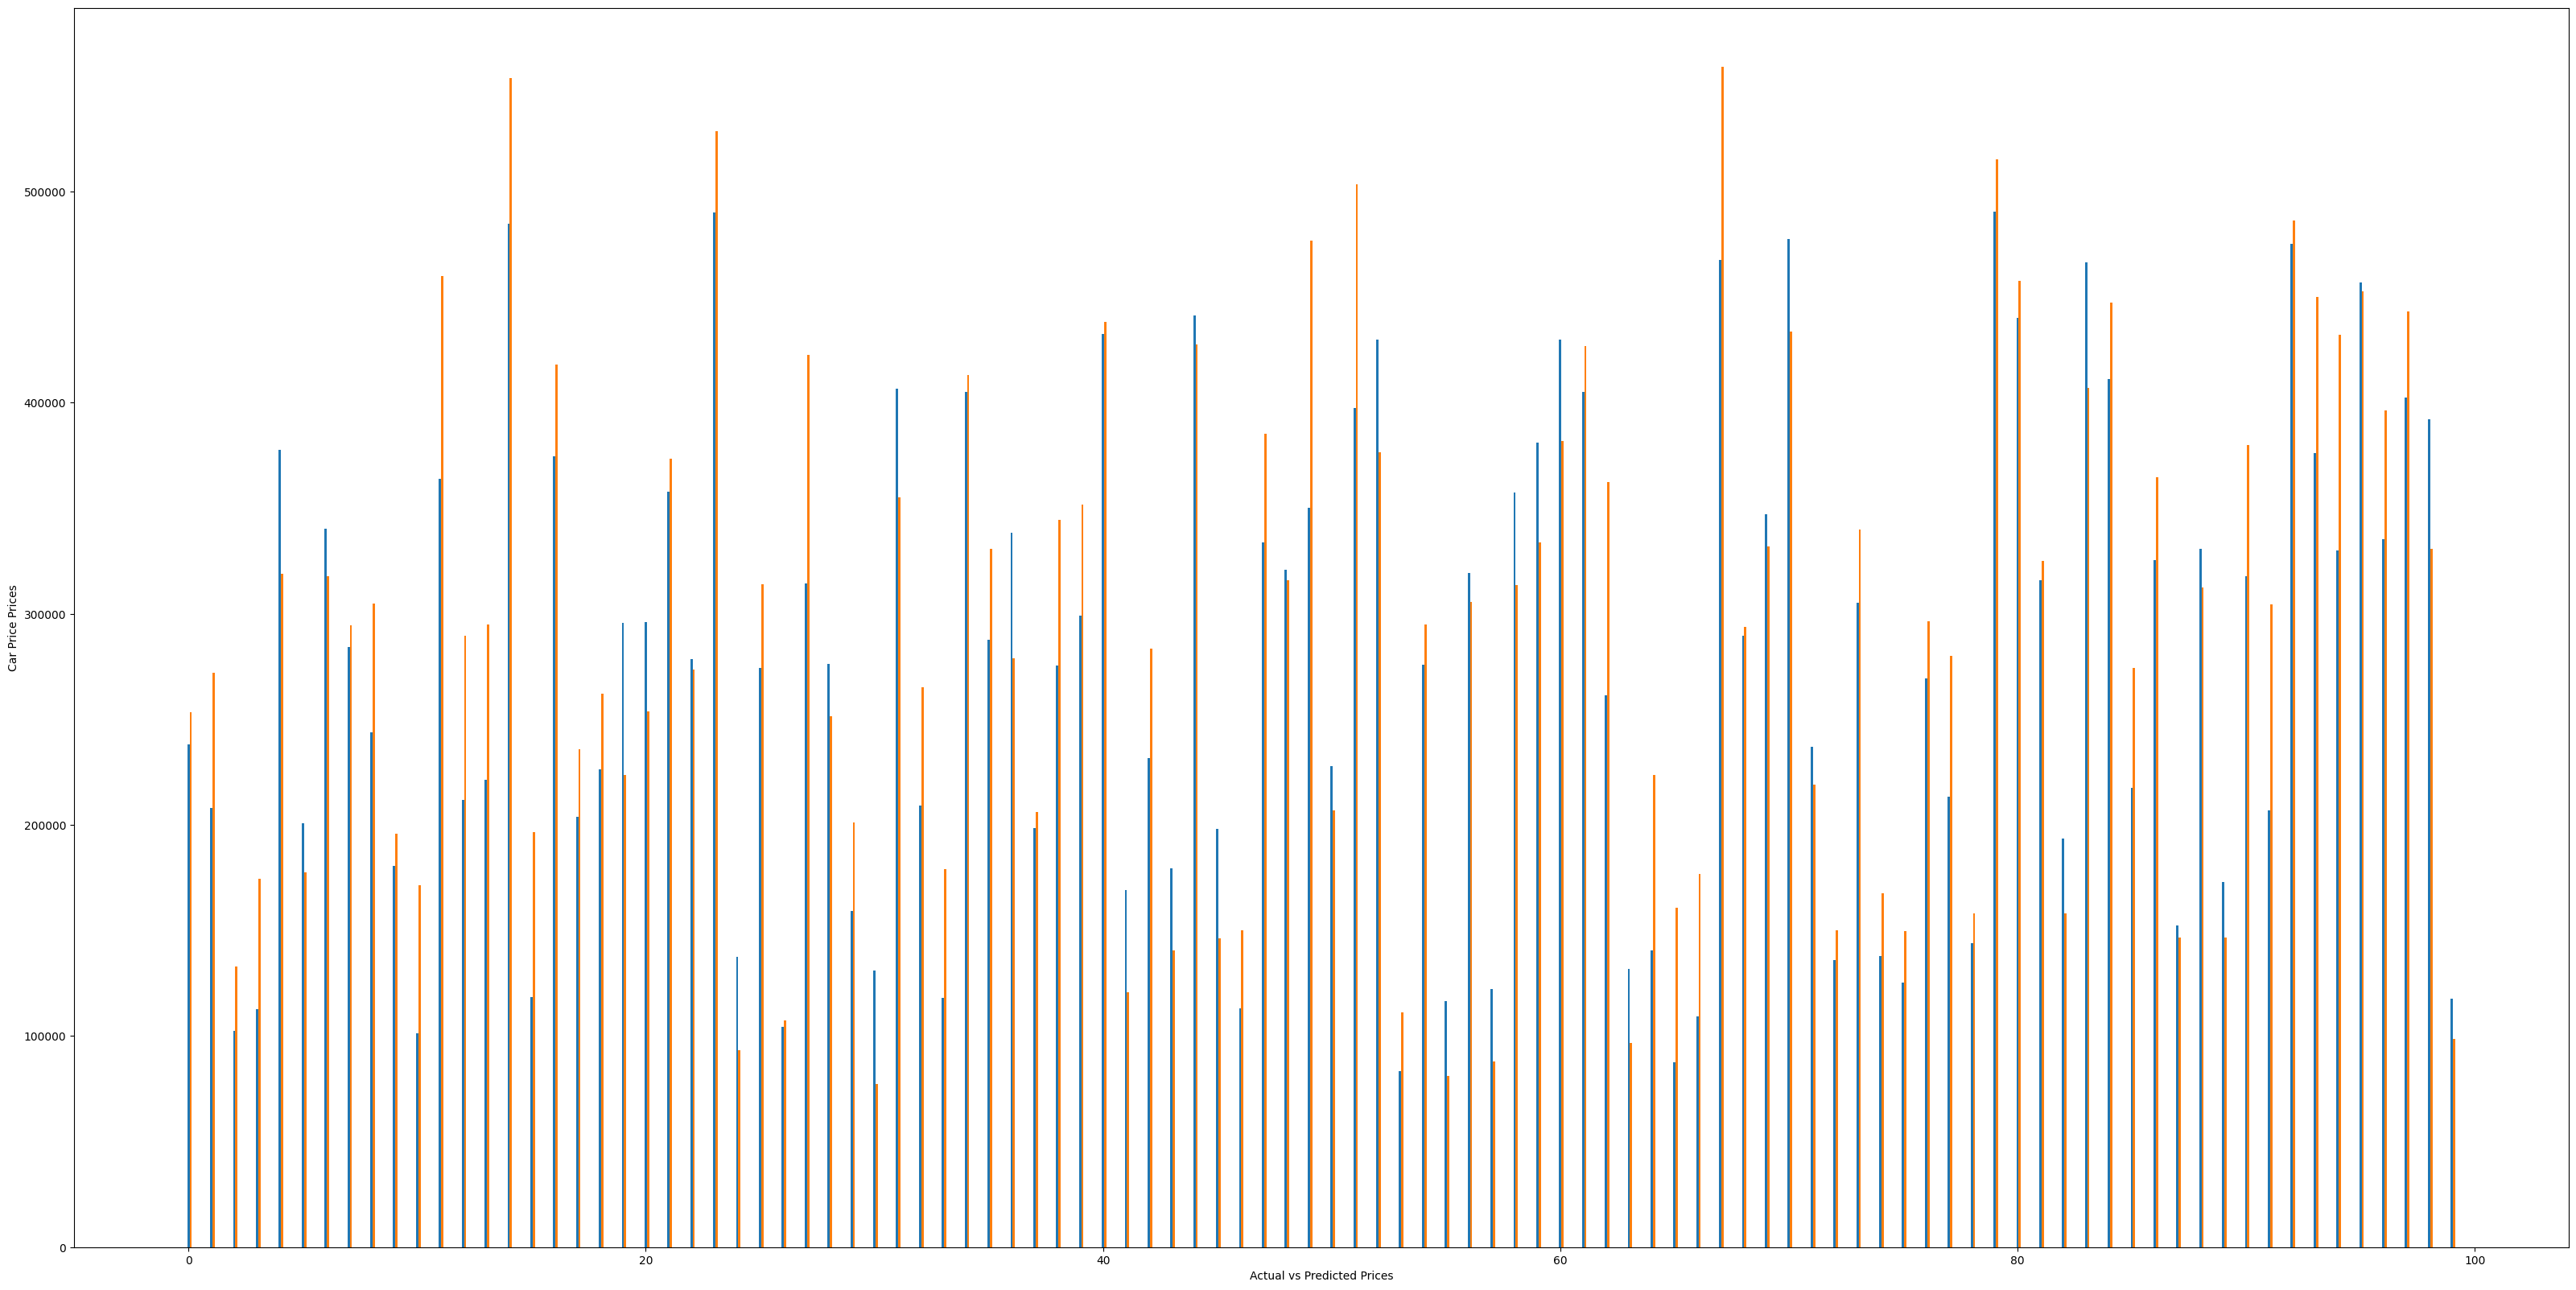

In [54]:
ind = np.arange(100)
plt.figure(figsize=(40,20))

width = 0.1

plt.bar(ind, y_pred, width, label='Predicted Car Price')
plt.bar(ind + width, y_true, width, label='Actual Car Price')

plt.xlabel('Actual vs Predicted Prices')
plt.ylabel('Car Price Prices')

plt.show()

#### Training approach 2


In [ ]:
model = tf.keras.Sequential([
    normalizer,
    Dense(1)
], 
name = "first-model-002"
)
model.summary()

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.1),
              loss = tf.keras.losses.MeanAbsoluteError(),
              metrics = [tf.keras.metrics.RootMeanSquaredError()],
              )

In [ ]:
history = model.fit(X, y, 
                    epochs=100, 
                    verbose=1,
                    validation_split=0.2
                    )

In [ ]:
model.summary()

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val_loss'])
plt.show()

In [ ]:
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('model performance')
plt.ylabel('rmse')
plt.xlabel('epoch')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

In [ ]:
X_test[:5], y_test[:5]

In [ ]:
y_pred5 = model.predict(X_test[:5])

In [ ]:
y_pred5